<a href="https://colab.research.google.com/github/alvinARYA96/worker-stress-data-cleaning/blob/main/Data_Cleaning_Homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Library dan Load Data

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('https://raw.githubusercontent.com/alvinARYA96/worker-stress-data-cleaning/refs/heads/main/data/stress_worker_dataset.csv')
df

,umur,jenis_kelamin,pekerjaan,gaji,is_menikah,berat,tinggi,is_merokok,pendidikan,ever_stress
0,27.0,Perempuan,PNS,7.957453e+06,1.0,54.315053,170.428542,1.0,S1,1
1,53.0,Perempuan,PNS,7.633003e+06,1.0,72.873404,165.530097,0.0,S1,1
2,37.0,Perempuan,Pegawai swasta,6.637625e+06,1.0,46.321533,154.599388,0.0,S1,1
3,36.0,Perempuan,Pengangguran,3.624871e+06,1.0,51.539781,167.340481,1.0,SD,1
4,38.0,Laki-laki,Freelance,6.031808e+06,1.0,60.726909,165.514773,1.0,S2,0
...,...,...,...,...,...,...,...,...,...,...
7912,32.0,Laki-laki,Pegawai swasta,6.024409e+06,1.0,44.432438,154.578859,0.0,SMA,1
7913,34.0,Laki-laki,Pegawai swasta,1.007043e+07,1.0,49.389914,158.782726,1.0,S1,1
7914,58.0,Laki-laki,Freelance,8.010815e+06,1.0,54.351968,154.478087,1.0,S2,1
7915,30.0,NaN,PNS,9.059906e+06,1.0,57.646930,163.377717,0.0,S1,1


## Data Profiling

In [2]:
# Data Profiling

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7917 entries, 0 to 7916
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   umur           7838 non-null   float64
 1   jenis_kelamin  7840 non-null   object 
 2   pekerjaan      7760 non-null   object 
 3   gaji           7843 non-null   float64
 4   is_menikah     7845 non-null   float64
 5   berat          7861 non-null   float64
 6   tinggi         7843 non-null   float64
 7   is_merokok     7847 non-null   float64
 8   pendidikan     7847 non-null   object 
 9   ever_stress    7917 non-null   int64  
dtypes: float64(6), int64(1), object(3)
memory usage: 618.6+ KB


###  Hasil Data Profiling & Rencana Eksekusi

#### 1. Dimensi & Kapasitas Data
- **Total Baris:** 7.917 entries
- **Total Kolom:** 10 columns

#### 2. Kelengkapan Data (Deteksi *Missing Values*)
Kolom dengan *Non-Null Count* di bawah 7.917 memiliki data kosong:

- **Data Lengkap 100%:** `ever_stress`
- **Data Kosong < 2% (semua kolom lainnya):** `umur`, `jenis_kelamin`, `pekerjaan`, `gaji`, `is_menikah`, `berat`, `tinggi`, `is_merokok`, `pendidikan`
  - *Tindakan untuk kolom numerik (`umur`, `gaji`, `berat`, `tinggi`):* Drop Row — karena < 5%, aman untuk dibuang tanpa mengorbankan banyak data.
  - *Tindakan untuk kolom kategorikal (`jenis_kelamin`, `pekerjaan`, `pendidikan`):* Imputasi Modus — lebih efisien daripada membuang baris.
  - *Tindakan untuk kolom biner (`is_menikah`, `is_merokok`):* Imputasi Modus — karena hanya punya 2 nilai (0/1), nilai yang paling sering muncul adalah pilihan terbaik.

#### 3. Pengecekan Tipe Data (*Dtype*)
- **Angka (`float64`):** `umur`, `gaji`, `is_menikah`, `berat`, `tinggi`, `is_merokok`
- **Teks (`object`):** `jenis_kelamin`, `pekerjaan`, `pendidikan`
- **Integer (`int64`):** `ever_stress`
- **Anomali Tipe Data:** `is_menikah` dan `is_merokok` bertipe `float64`, padahal seharusnya bertipe `int` (karena hanya berisi nilai 0 dan 1).


## Data Duplicate

In [4]:
# Data Duplicate (Berapa Banyak Duplikat?)

df.duplicated().sum()

np.int64(82)

In [5]:
# Data Duplicate (Intip Duplikat)

df[df.duplicated(keep=False)].sort_values('pekerjaan')

,umur,jenis_kelamin,pekerjaan,gaji,is_menikah,berat,tinggi,is_merokok,pendidikan,ever_stress
7871,43.0,Laki-laki,Freelance,9.985442e+06,1.0,51.487530,174.433625,0.0,S1,1
1429,44.0,Perempuan,Freelance,1.276151e+07,1.0,49.207348,159.630458,0.0,S1,1
7861,42.0,Laki-laki,Freelance,8.226076e+06,1.0,48.516840,164.534824,1.0,S1,1
7858,36.0,Laki-laki,Freelance,1.334245e+07,1.0,60.850950,166.500430,0.0,S1,1
2955,47.0,Laki-laki,Freelance,1.598578e+07,1.0,63.026569,165.867717,1.0,S1,1
...,...,...,...,...,...,...,...,...,...,...
6950,51.0,Perempuan,NaN,9.849026e+06,1.0,59.399949,170.190510,1.0,SMP,1
7354,53.0,Laki-laki,NaN,5.608065e+06,1.0,53.582806,157.633048,0.0,SMA,0
7840,51.0,Perempuan,NaN,9.849026e+06,1.0,59.399949,170.190510,1.0,SMP,1
7842,33.0,Laki-laki,NaN,1.589660e+07,1.0,66.036619,163.923159,0.0,S1,1


In [6]:
# Data Duplicate (Hapus Secara Permanen)

df.drop_duplicates(inplace=True)
print('Sisa baris setelah drop duplikat:', len(df))

Sisa baris setelah drop duplikat: 7835


In [7]:
# Pastikan Data Duplicate Sudah Hilang

print('Jumlah duplikat tersisa:', df.duplicated().sum())

Jumlah duplikat tersisa: 0


ditemukan **82 baris duplikat** dalam dataset. Semua baris duplikat telah berhasil dihapus menggunakan `drop_duplicates()`

## Missing Value

In [9]:
# Cek persentase Missing Value per kolom

mv_pct = df.isnull().sum() / len(df) * 100
print(mv_pct.round(2).to_string())

umur             1.01
jenis_kelamin    0.96
pekerjaan        1.97
gaji             0.93
is_menikah       0.89
berat            0.71
tinggi           0.94
is_merokok       0.88
pendidikan       0.88
ever_stress      0.00


Semua kolom yang memiliki missing value berada di bawah **2%**, sehingga strategi utamanya adalah **Drop Row** untuk kolom numerik dan **Imputasi Modus** untuk kolom kategorikal & biner.

In [10]:
# A. Drop Rows untuk kolom numerik (umur, gaji, berat, tinggi)

df = df.dropna(subset=['umur', 'gaji', 'berat', 'tinggi'])
print('Sisa baris setelah drop rows numerik:', len(df))

Sisa baris setelah drop rows numerik: 7558


In [13]:
# B. Imputasi Modus untuk kolom kategorikal (jenis_kelamin, pekerjaan, pendidikan)


for col in ['jenis_kelamin', 'pekerjaan', 'pendidikan']:
    modus = df[col].mode()[0]
    df[col] = df[col].fillna(modus)
    print(f'Imputasi {col} dengan modus: "{modus}"')

Imputasi jenis_kelamin dengan modus: "Laki-laki"
Imputasi pekerjaan dengan modus: "Pegawai swasta"
Imputasi pendidikan dengan modus: "S1"


/tmp/ipykernel_1623/4167225389.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna(modus)


In [14]:
# C. Imputasi Modus untuk kolom biner (is_menikah, is_merokok)

for col in ['is_menikah', 'is_merokok']:
    modus = df[col].mode()[0]
    df[col] = df[col].fillna(modus)
    print(f'Imputasi {col} dengan modus: {modus}')

Imputasi is_menikah dengan modus: 1.0
Imputasi is_merokok dengan modus: 0.0


/tmp/ipykernel_1623/3886843083.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna(modus)


In [16]:
# Verifikasi missing value

print('Sisa Missing Value per kolom:')
print(df.isnull().sum().to_string())

Sisa Missing Value per kolom:
umur             0
jenis_kelamin    0
pekerjaan        0
gaji             0
is_menikah       0
berat            0
tinggi           0
is_merokok       0
pendidikan       0
ever_stress      0


## Outlier

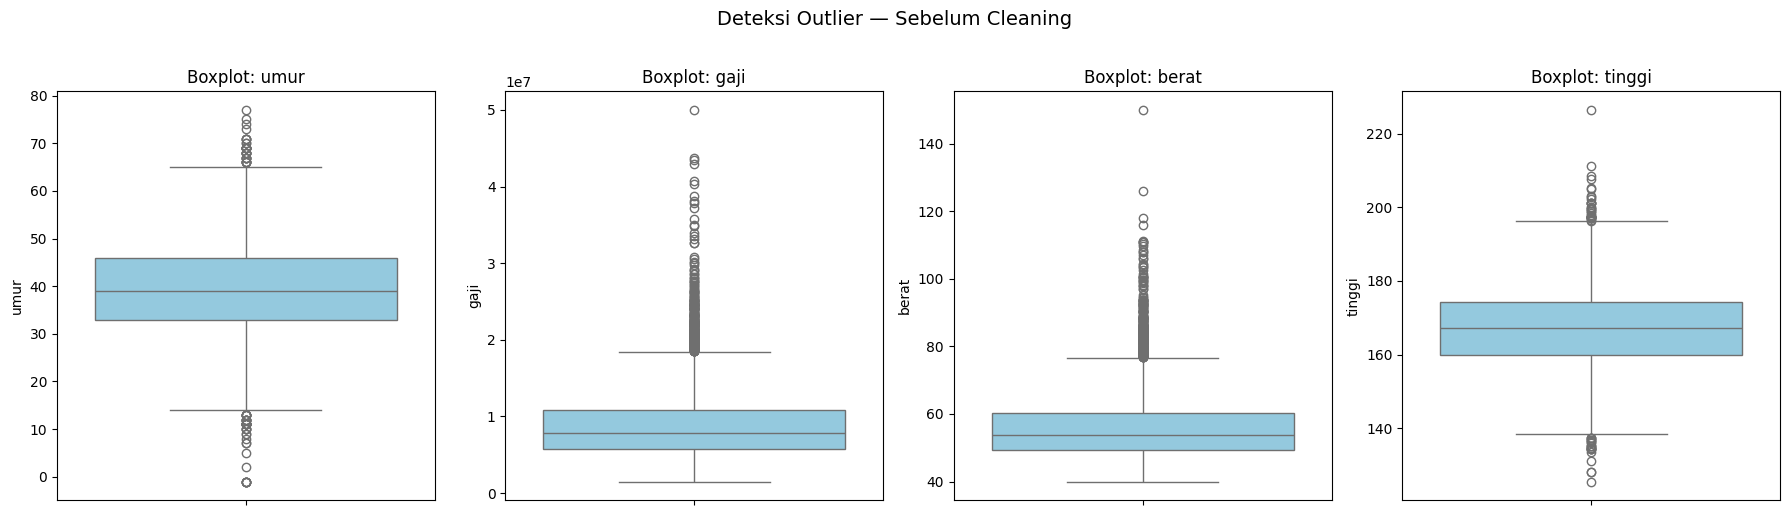

In [17]:
# Visualisasi distribusi kolom numerik untuk deteksi outlier

kolom_numerik = ['umur', 'gaji', 'berat', 'tinggi']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, col in enumerate(kolom_numerik):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot: {col}')
plt.suptitle('Deteksi Outlier — Sebelum Cleaning', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [18]:
# Cek nilai min & max tiap kolom numerik

print('=== Ringkasan Nilai Ekstrem ===')
for col in kolom_numerik:
    print(f'{col:<8} | min: {df[col].min():.2f}  | max: {df[col].max():.2f}')

=== Ringkasan Nilai Ekstrem ===
umur     | min: -1.00  | max: 77.00
gaji     | min: 1500000.00  | max: 50000000.00
berat    | min: 40.00  | max: 150.00
tinggi   | min: 125.49  | max: 226.45


In [19]:
# A. Hapus outlier tidak masuk akal — umur bernilai negatif (-1)

print('Baris dengan umur tidak valid (< 0):')
print(df[df['umur'] < 0])

df = df[df['umur'] >= 0]
print(f'\nSisa baris setelah hapus umur negatif: {len(df)}')

Baris dengan umur tidak valid (< 0):
     umur jenis_kelamin       pekerjaan          gaji  is_menikah      berat  \
225  -1.0     Laki-laki  Pegawai swasta  8.428640e+06         1.0  51.625352   
247  -1.0     Laki-laki    Pengangguran  8.936972e+06         1.0  54.817264   
402  -1.0     Perempuan  Pegawai swasta  6.483068e+06         1.0  47.257092   
481  -1.0     Laki-laki  Pegawai swasta  6.491602e+06         1.0  54.020104   
559  -1.0     Laki-laki             PNS  1.361686e+07         1.0  54.653641   
650  -1.0     Laki-laki  Pegawai swasta  3.317426e+06         1.0  65.170185   

         tinggi  is_merokok pendidikan  ever_stress  
225  172.534456         1.0         S1            1  
247  176.969025         1.0        SMP            1  
402  150.874104         1.0         S1            1  
481  156.483096         1.0        SMA            1  
559  165.107133         1.0         S1            1  
650  169.840559         0.0        SMP            1  

Sisa baris setelah hapu

In [20]:
# B. Validasi outlier gaji 50 juta — apakah wajar?

cek_gaji_tinggi = df[df['gaji'] >= 40000000]
print('Validasi Outlier Gaji >= 40 Juta:')
print(cek_gaji_tinggi[['pekerjaan', 'pendidikan', 'gaji']].to_string())

Validasi Outlier Gaji >= 40 Juta:
           pekerjaan pendidikan         gaji
591        Freelance        SMA  43692000.77
2072  Pegawai swasta         S1  42972549.68
3219  Pegawai swasta         S1  40685460.35
4201             PNS         S2  40375805.26
5331             PNS        SMA  43526801.93
7452             PNS         S2  50000000.00


### Razia Outliers: Menangani Data Ekstrem (Penjelasan Code)

- **A. Menghapus Outlier "Error Input" (Tidak Masuk Akal)**
  - **Kolom:** `umur` dengan nilai **-1**
  - **Fungsi:** `df = df[df['umur'] >= 0]`
  - **Alasan:** Secara logika dasar, tidak ada manusia yang berusia negatif. Ini adalah kesalahan input data (*data entry error*) yang harus dihapus. Saya menggunakan teknik **filter** (bukan drop) untuk hanya mempertahankan baris dengan umur yang valid (≥ 0).

- **B. Mempertahankan Outlier "Fakta Lapangan" (Valid)**
  - **Kolom:** `gaji` dengan nilai hingga **Rp 50.000.000**
  - **Alasan:** Ketika kita cek silang (*cross-check*) dengan kolom `pekerjaan` dan `pendidikan`, ternyata gaji tinggi ini dimiliki oleh responden dengan latar belakang pendidikan tinggi dan pekerjaan profesional. Ini adalah **fakta nyata**, bukan error. Jika dihapus data ini secara membabi buta, analisa pendapatannya akan menjadi tidak akurat dan bias ke bawah.


## Data Inkonsisten

In [21]:
# Cek nilai unik kolom kategorikal

for col in ['jenis_kelamin', 'pekerjaan', 'pendidikan']:
    print(f'\nNilai unik [{col}]:', df[col].unique())



Nilai unik [jenis_kelamin]: ['Perempuan' 'Laki-laki']

Nilai unik [pekerjaan]: ['PNS' 'Pegawai swasta' 'Pengangguran' 'Freelance']

Nilai unik [pendidikan]: ['S1' 'SD' 'S2' 'SMA' 'SMP' 'S3']


In [22]:
# Cek tipe data saat ini

print('Tipe data sebelum perbaikan:')
print(df[['is_menikah', 'is_merokok', 'umur']].dtypes)

Tipe data sebelum perbaikan:
is_menikah    float64
is_merokok    float64
umur          float64
dtype: object


In [26]:
# A. Memperbaiki tipe data kolom biner: float64 → int
# is_menikah dan is_merokok seharusnya hanya berisi 0 dan 1 (bilangan bulat, bukan desimal)

df['is_menikah'] = df['is_menikah'].astype(int)
df['is_merokok']  = df['is_merokok'].astype(int)

print('Tipe data setelah perbaikan:')
print(df[['is_menikah', 'is_merokok']].dtypes)

Tipe data setelah perbaikan:
is_menikah    int64
is_merokok    int64
dtype: object


/tmp/ipykernel_1623/2728661793.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['is_menikah'] = df['is_menikah'].astype(int)
/tmp/ipykernel_1623/2728661793.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['is_merokok']  = df['is_merokok'].astype(int)


In [27]:
# B. Memperbaiki tipe data kolom umur: float64 → int
# Umur adalah bilangan bulat, tidak perlu desimal

df['umur'] = df['umur'].astype(int)

print('Tipe data umur setelah perbaikan:', df['umur'].dtype)

Tipe data umur setelah perbaikan: int64


/tmp/ipykernel_1623/1505174482.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['umur'] = df['umur'].astype(int)


In [28]:
# C. Menyeragamkan format teks kolom kategorikal (Title Case)
# Mencegah masalah aggregasi akibat perbedaan huruf kapital (misal: 'pns' vs 'PNS' vs 'Pns')

for col in ['jenis_kelamin', 'pekerjaan', 'pendidikan']:
    df[col] = df[col].str.strip().str.title()

print('Nilai unik setelah standardisasi:')
for col in ['jenis_kelamin', 'pekerjaan', 'pendidikan']:
    print(f'  {col}:', df[col].unique())

Nilai unik setelah standardisasi:
  jenis_kelamin: ['Perempuan' 'Laki-Laki']
  pekerjaan: ['Pns' 'Pegawai Swasta' 'Pengangguran' 'Freelance']
  pendidikan: ['S1' 'Sd' 'S2' 'Sma' 'Smp' 'S3']


/tmp/ipykernel_1623/4200603642.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].str.strip().str.title()


### Perbaikan Inkonsistensi Data (Penjelasan Code)

- **A. Konversi Tipe Data Biner (`is_menikah`, `is_merokok`): `float64` → `int`**
  - **Fungsi:** `df[col].astype(int)`
  - **Alasan:** Kolom `is_menikah` dan `is_merokok` seharusnya hanya berisi nilai `0` atau `1` (bilangan bulat). Tipe `float64` muncul karena sebelumnya ada *missing values* (pandas secara otomatis mengubah kolom integer yang memiliki NaN menjadi float). Setelah *missing values* ditangani, dikembalikan ke tipe yang benar.

- **B. Konversi Tipe Data Umur (`umur`): `float64` → `int`**
  - **Fungsi:** `df['umur'].astype(int)`
  - **Alasan:** Umur seseorang adalah bilangan bulat — tidak masuk akal menyimpannya sebagai `27.0` padahal `27` sudah cukup. Perbaikan ini membuat data lebih representatif dan efisien secara memori.

- **C. Standardisasi Format Teks (Title Case)**
  - **Fungsi:** `df[col].str.strip().str.title()`
  - **Alasan:** `.str.strip()` membersihkan spasi tersembunyi di awal/akhir teks, sementara `.str.title()` memastikan semua kata diawali huruf kapital. Ini penting agar proses *Group By* nantinya tidak menghasilkan kelompok ganda hanya karena perbedaan huruf kapital (misal: `'pns'` dan `'Pns'` dianggap dua kategori berbeda).

##  Verifikasi Akhir — Data Setelah Cleaning


In [29]:
print('=== RINGKASAN HASIL DATA CLEANING ===')
print(f'Jumlah baris awal  : 7.917')
print(f'Jumlah baris akhir : {len(df)}')
print(f'Baris yang dibuang : {7917 - len(df)}')
print()
print('Missing value tersisa:')
print(df.isnull().sum().to_string())
print()
print('Duplikat tersisa:', df.duplicated().sum())

=== RINGKASAN HASIL DATA CLEANING ===
Jumlah baris awal  : 7.917
Jumlah baris akhir : 7552
Baris yang dibuang : 365

Missing value tersisa:
umur             0
jenis_kelamin    0
pekerjaan        0
gaji             0
is_menikah       0
berat            0
tinggi           0
is_merokok       0
pendidikan       0
ever_stress      0

Duplikat tersisa: 0


In [30]:
# info final
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7552 entries, 0 to 7834
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   umur           7552 non-null   int64  
 1   jenis_kelamin  7552 non-null   object 
 2   pekerjaan      7552 non-null   object 
 3   gaji           7552 non-null   float64
 4   is_menikah     7552 non-null   int64  
 5   berat          7552 non-null   float64
 6   tinggi         7552 non-null   float64
 7   is_merokok     7552 non-null   int64  
 8   pendidikan     7552 non-null   object 
 9   ever_stress    7552 non-null   int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 649.0+ KB


In [33]:
# sampel data bersih
df.head(10)

,umur,jenis_kelamin,pekerjaan,gaji,is_menikah,berat,tinggi,is_merokok,pendidikan,ever_stress
0,27,Perempuan,Pns,7.957453e+06,1,54.315053,170.428542,1,S1,1
1,53,Perempuan,Pns,7.633003e+06,1,72.873404,165.530097,0,S1,1
2,37,Perempuan,Pegawai Swasta,6.637625e+06,1,46.321533,154.599388,0,S1,1
3,36,Perempuan,Pengangguran,3.624871e+06,1,51.539781,167.340481,1,Sd,1
4,38,Laki-Laki,Freelance,6.031808e+06,1,60.726909,165.514773,1,S2,0
5,55,Perempuan,Pns,9.213032e+06,1,54.287045,179.235145,0,S1,0
6,40,Perempuan,Freelance,1.068256e+07,1,54.824881,177.431122,0,S1,0
7,47,Laki-Laki,Pegawai Swasta,4.508321e+06,1,74.795152,170.540938,1,S2,0
8,41,Laki-Laki,Freelance,9.846426e+06,1,55.049547,157.192078,0,Sma,1
9,46,Perempuan,Freelance,9.257426e+06,1,52.764656,174.397170,0,S1,1


## Kesimpulan Akhir:

Berikut ringkasan seluruh langkah yang telah saya lakukan:

| Langkah | Masalah Ditemukan | Tindakan | Hasil |
|---|---|---|---|
| **Duplicate** | 82 baris duplikat | `drop_duplicates()` | 82 baris dihapus |
| **Missing Value** | < 2% di semua kolom | Drop row (numerik), Imputasi Modus (kategorikal & biner) | 0 missing value tersisa |
| **Outlier** | `umur` = -1, `gaji` = 50 juta | Hapus umur negatif, pertahankan gaji tinggi (valid) | Data logis & akurat |
| **Inkonsisten** | Dtype float pada `is_menikah`, `is_merokok`, `umur` | Konversi ke `int`, standardisasi Title Case | Tipe data sesuai & teks seragam |
